In [26]:
!git clone https://github.com/pratyu2h/Summer-projects.git
%cd Summer-projects/bitcoin
!pip install -q ta faiss-cpu kaggle google-genai

c:\Users\PRATYUSH\OneDrive\Desktop\college\cses\Summer-projects\bitcoin\Summer-projects\bitcoin\Summer-projects\bitcoin\Summer-projects\bitcoin


Cloning into 'Summer-projects'...

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\PRATYUSH\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [45]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\PRATYUSH\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [27]:
%pip install -q python-dotenv

import os
from dotenv import load_dotenv

load_dotenv()

print("Gemini API key configured:", bool(os.getenv("GEMINI_API_KEY")))

Note: you may need to restart the kernel to use updated packages.
Gemini API key configured: True



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\PRATYUSH\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [28]:
from pathlib import Path

csv_path = Path(r"C:\Users\PRATYUSH\OneDrive\Desktop\college\cses\btcusd_1-min_data.csv")

print(f"Using local Bitcoin data: {csv_path}")

Using local Bitcoin data: C:\Users\PRATYUSH\OneDrive\Desktop\college\cses\btcusd_1-min_data.csv


In [29]:
import pandas as pd

df_raw = pd.read_csv(csv_path)
df_raw = df_raw.rename(columns={c: c.strip() for c in df_raw.columns})
df_raw = df_raw.tail(200_000).reset_index(drop=True)  # last ~140 days of 1-min bars; raise/lower to trade off train time vs. data volume
print(df_raw.shape)
df_raw.head()

(200000, 6)


,Timestamp,Open,High,Low,Close,Volume
0,1.766545e+09,87127.0,87127.0,87105.0,87110.0,0.532630
1,1.766545e+09,87110.0,87119.0,87097.0,87119.0,0.160547
2,1.766545e+09,87115.0,87115.0,87099.0,87100.0,0.027078
3,1.766545e+09,87099.0,87099.0,87095.0,87095.0,0.117742
4,1.766545e+09,87095.0,87095.0,87079.0,87079.0,0.010041


FEATURE AND WINDOW

In [30]:
from data import build_feature_frame, make_windows, time_split, BTCWindowDataset, ALL_FEATURES
from torch.utils.data import DataLoader

feat_df = build_feature_frame(df_raw, timestamp_col="Timestamp", timestamp_is_unix=True)
windows = make_windows(feat_df, seq_len=60, features=ALL_FEATURES)

train_idx, val_idx, test_idx = time_split(len(windows.X), train_frac=0.7, val_frac=0.15)
print(f"train={train_idx.stop} val={val_idx.stop-train_idx.stop} test={len(windows.X)-val_idx.stop}")

train=139076 val=29802 test=29802


In [31]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X_train_flat = windows.X[train_idx].reshape(-1, windows.X.shape[-1])
scaler = StandardScaler().fit(X_train_flat)

def scale(X):
    shape = X.shape
    return scaler.transform(X.reshape(-1, shape[-1])).reshape(shape).astype(np.float32)  # changed from np.float32 to np.int64 for compatibility with certain models

X_train, X_val, X_test = scale(windows.X[train_idx]), scale(windows.X[val_idx]), scale(windows.X[test_idx])
y_train, y_val, y_test = windows.y[train_idx], windows.y[val_idx], windows.y[test_idx]
ts_train = windows.timestamps[train_idx].reset_index(drop=True)

train_ds = BTCWindowDataset(X_train, y_train)
val_ds = BTCWindowDataset(X_val, y_val)
test_ds = BTCWindowDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
train_loader_noshuffle = DataLoader(train_ds, batch_size=64, shuffle=False)  # for building the retrieval index -- order must match ts_train
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

TRAIN

In [33]:
import torch
from model import BTCForecaster

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = BTCForecaster(num_features=len(ALL_FEATURES), hidden_size=128, num_layers=2, cell_type="gru", dropout=0.2)

from train import train_base_model
model, history = train_base_model(model, train_loader, val_loader, device, epochs=30, lr=1e-3, patience=5)

cuda
epoch 1/30  train_loss=0.000029  val_loss=0.000000
epoch 2/30  train_loss=0.000000  val_loss=0.000000
epoch 3/30  train_loss=0.000000  val_loss=0.000000
epoch 4/30  train_loss=0.000000  val_loss=0.000000
epoch 5/30  train_loss=0.000000  val_loss=0.000000
epoch 6/30  train_loss=0.000000  val_loss=0.000001
epoch 7/30  train_loss=0.000000  val_loss=0.000000
epoch 8/30  train_loss=0.000000  val_loss=0.000000
  early stopping at epoch 8 (no val improvement for 5 epochs)


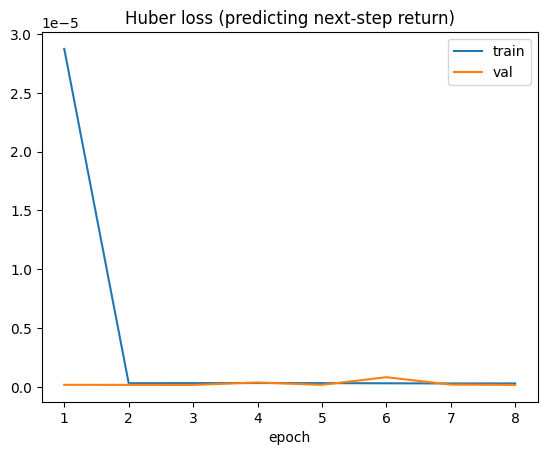

In [35]:
import matplotlib.pyplot as plt

epochs_r = [h["epoch"] for h in history]
plt.plot(epochs_r, [h["train_loss"] for h in history], label="train")
plt.plot(epochs_r, [h["val_loss"] for h in history], label="val")
plt.title("Huber loss (predicting next-step return)")
plt.xlabel("epoch"); plt.legend(); plt.show()

FAISS RETRIEVAL

In [36]:
from retrieval import build_retriever

retriever = build_retriever(model, train_loader_noshuffle, ts_train, device)
print(f"Indexed {retriever.index.ntotal} historical windows, embedding dim {retriever.dim}")

Indexed 139076 historical windows, embedding dim 128


TRAIN AND COMPARE AGAIN

In [37]:
from train import compute_retrieval_features, train_blend_head, rmse

tr_raw, tr_rmean, tr_rstd, tr_y = compute_retrieval_features(model, train_loader_noshuffle, retriever, device)
va_raw, va_rmean, va_rstd, va_y = compute_retrieval_features(model, val_loader, retriever, device)
te_raw, te_rmean, te_rstd, te_y = compute_retrieval_features(model, test_loader, retriever, device)

blend = train_blend_head(tr_raw, tr_rmean, tr_rstd, tr_y, va_raw, va_rmean, va_rstd, va_y, device, epochs=200)

with torch.no_grad():
    blended_test_pred = blend(
        torch.from_numpy(te_raw).float().to(device),
        torch.from_numpy(te_rmean).float().to(device),
        torch.from_numpy(te_rstd).float().to(device),
    ).cpu().numpy()

print(f"Test RMSE, raw forecast only:      {rmse(te_raw, te_y):.6f}")
print(f"Test RMSE, retrieval-blended:      {rmse(blended_test_pred, te_y):.6f}")
print(f"Naive baseline (predict 0 return): {rmse(np.zeros_like(te_y), te_y):.6f}")

blend head trained, best val_loss=0.000000
Test RMSE, raw forecast only:      0.000452
Test RMSE, retrieval-blended:      0.000449
Naive baseline (predict 0 return): 0.000448


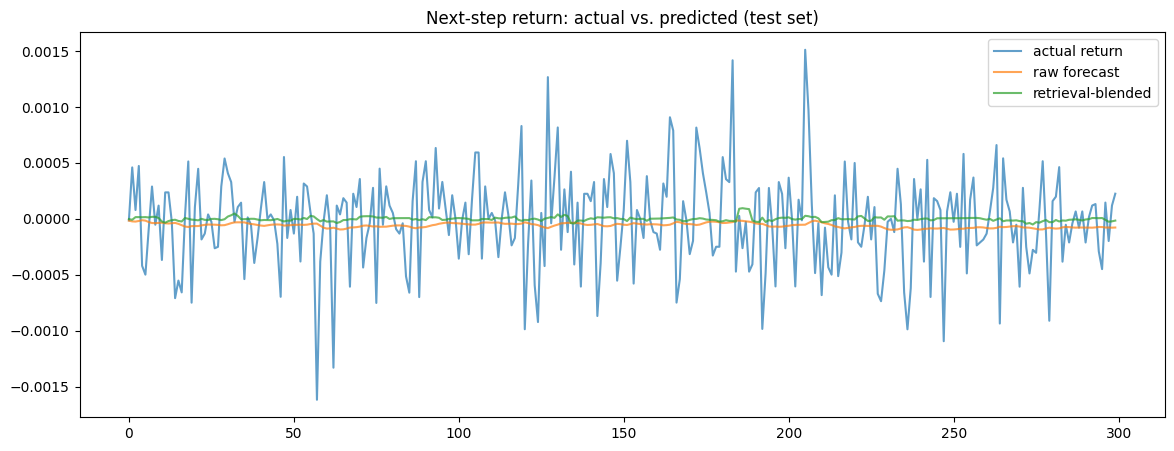

In [38]:
plt.figure(figsize=(14,5))
n_show = 300
plt.plot(te_y[:n_show], label="actual return", alpha=0.7)
plt.plot(te_raw[:n_show], label="raw forecast", alpha=0.7)
plt.plot(blended_test_pred[:n_show], label="retrieval-blended", alpha=0.7)
plt.legend(); plt.title("Next-step return: actual vs. predicted (test set)"); plt.show()

GEMINI RAG ARCH.


In [42]:
import os
import importlib
from pathlib import Path
from dotenv import load_dotenv

# Locate .env in the Bitcoin project directory.
env_path = Path.cwd() / ".env"
if not env_path.exists():
    env_path = Path(
        r"C:\Users\PRATYUSH\OneDrive\Desktop\college\cses\Summer-projects\bitcoin\.env"
    )

if not env_path.exists():
    raise FileNotFoundError(f".env file not found: {env_path}")

load_dotenv(env_path, override=True)

if not os.getenv("GEMINI_API_KEY"):
    raise RuntimeError(f"GEMINI_API_KEY was not loaded from: {env_path}")

# Reload the module so the current .env and source code are used.
import gemini_reasoning
importlib.reload(gemini_reasoning)

from gemini_reasoning import build_prompt, get_market_commentary

idx = 0
sample_X = torch.from_numpy(X_test[idx:idx + 1]).float().to(device)

with torch.no_grad():
    encoded = model.encode(sample_X)
    emb = encoded.cpu().numpy()[0]
    raw_pred = float(model.head(encoded).squeeze(-1).cpu().numpy()[0])

neighbors = retriever.query(emb, k=5)
w_mean, std = retriever.query_batch_stats(emb.reshape(1, -1), k=5)

with torch.no_grad():
    blended_pred = float(
        blend(
            torch.tensor([raw_pred]).float().to(device),
            torch.from_numpy(w_mean).float().to(device),
            torch.from_numpy(std).float().to(device),
        )
        .cpu()
        .numpy()[0]
    )

current_indicators = {
    "rsi": float(feat_df["rsi"].iloc[test_idx.start + idx + 59]),
    "macd": float(feat_df["macd"].iloc[test_idx.start + idx + 59]),
    "ema_20": float(feat_df["ema_20"].iloc[test_idx.start + idx + 59]),
}

model_name = os.getenv("GEMINI_MODEL", "gemini-2.5-flash-lite")

print(f"Loaded environment file: {env_path}")
print(f"Using Gemini model: {model_name}")

try:
    note = get_market_commentary(
        current_indicators=current_indicators,
        raw_pred=raw_pred,
        blended_pred=blended_pred,
        neighbors=neighbors,
        model_name=model_name,
    )
except Exception as exc:
    print(f"Gemini request failed: {exc}")
    note = build_prompt(
        current_indicators,
        raw_pred,
        blended_pred,
        neighbors,
    )
    note += (
        "\n\nGemini commentary was unavailable; "
        "the generated prompt is shown instead."
    )

print(note)

Loaded environment file: C:\Users\PRATYUSH\OneDrive\Desktop\college\cses\Summer-projects\bitcoin\.env
Using Gemini model: gemini-3.1-flash-lite
The model predicts a near-neutral next-step return for BTC/USD of -0.0009%, suggesting a state of equilibrium with minimal expected price movement. The historical analogs show significant volatility, with results ranging from -0.0334% to +0.0777%, indicating that the model lacks a strong directional consensus compared to its past similar patterns. Because the retrieved analogs show conflicting outcomes, the model's confidence in this specific prediction remains low. Please note that this is a backtested statistical output rather than financial advice, and historical market patterns do not guarantee future results.


RESULTS

In [44]:
import json

with open("training_history.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "base_model_history": history,
            "test_rmse_raw": float(rmse(te_raw, te_y)),
            "test_rmse_blended": float(rmse(blended_test_pred, te_y)),
        },
        f,
        indent=2,
    )

!git config --global user.email "Pratyush07sharma@gmail.com"
!git config --global user.name "Pratyu2h"
!git add training_history.json
!git commit -m "Add training history from Colab run"
!git push

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


Everything up-to-date
